In [3]:
import numpy as np
import pandas as pd

import torch
import torch_pruning as tp
import torch.ao.quantization

from src.dataset import *
from src.lightning import *
from src.models import *
from src.params import *
from src.utils import *
from src.deployment import *



In [ ]:

files_dir = PROCESSED_DIR / "cropped" / "files"
metadata = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 32, num_workers= 8, verbose= False)


#need to fuse model
fuse_list = FUSE_LIST

In [ ]:


#instantitate dataloaders 
dm.setup()

dummy_input = torch.randn(1,4,100,25)
imp = tp.importance.MagnitudeImportance(p= 2)


results_quantize = {
    "sizes_before": [], "latency_before": [], "score_before": [],
    "pruning_ratio": [], "sizes_after": [], 
    "latency_after": [], "score_after": []
}


[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273_min_vote_1.json
[setup] Cache loaded — 5 folds found


In [ ]:
for pruning_ratio in [0,0.1, 0.25, 0.4]:
    #define pruner
    model = instantiate_model(BEST_WEIGHTS_PATH)
    ignored_layers = get_ignored_layers(model)
    
    print(f"testing with pruning ratio {pruning_ratio}")
    pruner = tp.pruner.MagnitudePruner(model= model, example_inputs= dummy_input,
                                   importance = imp,
                                   pruning_ratio = pruning_ratio,
                                   ignored_layers= ignored_layers)

    #prune in place
    pruner.step()
    
    #load fine tuned weights for that pruned architecture into lightning module
    ckpt_list = list((CHECKPOINTS_DIR / f"pruning_{pruning_ratio}").glob("*ckpt"))

    #ckpt = ckpt_list[0] #only one checkpoint
    lit_model = BrainLightning.load_from_checkpoint(ckpt_list[0], model = model)
    
    # model efficience before quantization
    size_before, latency_before, score_before = quantized_model_efficience_report(lit_model.model, datamodule= dm)
    results_quantize["sizes_before"].append(size_before)
    results_quantize["latency_before"].append(latency_before)
    results_quantize["score_before"].append(score_before)
    results_quantize["pruning_ratio"].append(pruning_ratio)
    
    
    #quantization
    model_to_quant = lit_model.model
    model_to_quant.cpu().float().eval()

    model_wrapped = QuantWrapperCustom(model = model_to_quant)
    torch.backends.quantized.engine = "qnnpack"
    
    model_fused = torch.ao.quantization.fuse_modules(model_wrapped, fuse_list, inplace= False)
    model_fused.qconfig = torch.ao.quantization.get_default_qconfig("qnnpack")
    model_prepared  = torch.ao.quantization.prepare(model_fused)
    
    
        #calibration
    model_prepared.eval()
    cal_dataloader = dm.val_dataloader()
    with torch.no_grad():
        for x, _ in cal_dataloader:
            model_prepared(x.cpu())
            
    #conversion
    model_quantized = torch.ao.quantization.convert(model_prepared)
    size_after, latency_after, score_after = quantized_model_efficience_report(model_quantized, datamodule= dm)
    results_quantize["sizes_after"].append(size_after)
    results_quantize["latency_after"].append(latency_after)
    results_quantize["score_after"].append(score_after)
    
    
    

testing with pruning ratio 0
calculate model inference score

-----------------------------------
  Model Efficiency Report Quantization
-----------------------------------
  Model size (MB):     4.217
-----------------------------------
  Median latency (ms): 4.05
  Max latency (ms):    5.43
-----------------------------------
  KL score: 0.6754
-----------------------------------



/var/folders/dk/v6_xfc950bb08vyf1lm9v0x00000gn/T/ipykernel_92744/562958115.py:37: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared  = torch.ao.quantization.prepare(model_fused)
/var/folders/dk/v6_xfc950bb08vyf1lm9v0x00000gn/T/ipykernel_92744/562958115.py:48: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations o

calculate model inference score

-----------------------------------
  Model Efficiency Report Quantization
-----------------------------------
  Model size (MB):     1.064
-----------------------------------
  Median latency (ms): 2.57
  Max latency (ms):    9.24
-----------------------------------
  KL score: 0.6759
-----------------------------------

testing with pruning ratio 0.1
calculate model inference score

-----------------------------------
  Model Efficiency Report Quantization
-----------------------------------
  Model size (MB):     3.442
-----------------------------------
  Median latency (ms): 3.76
  Max latency (ms):    11.06
-----------------------------------
  KL score: 0.6780
-----------------------------------

calculate model inference score

-----------------------------------
  Model Efficiency Report Quantization
-----------------------------------
  Model size (MB):     0.870
-----------------------------------
  Median latency (ms): 2.28
  Max latency (ms

In [6]:
results_df = pd.DataFrame(results_quantize)
results_df

,sizes_before,latency_before,score_before,pruning_ratio,sizes_after,latency_after,score_after
0,4.217013,4.049937,0.675397,0.00,1.063870,2.574042,0.675909
1,3.442416,3.759292,0.678048,0.10,0.870206,2.284416,0.678543
2,2.510287,3.995605,0.681209,0.25,0.637113,1.917333,0.681632
3,1.688022,3.454813,0.685242,0.40,0.431546,1.814833,0.686190


In [ ]:
results_df.to_csv(DATA_DIR / "quantize_results.csv", index=False)


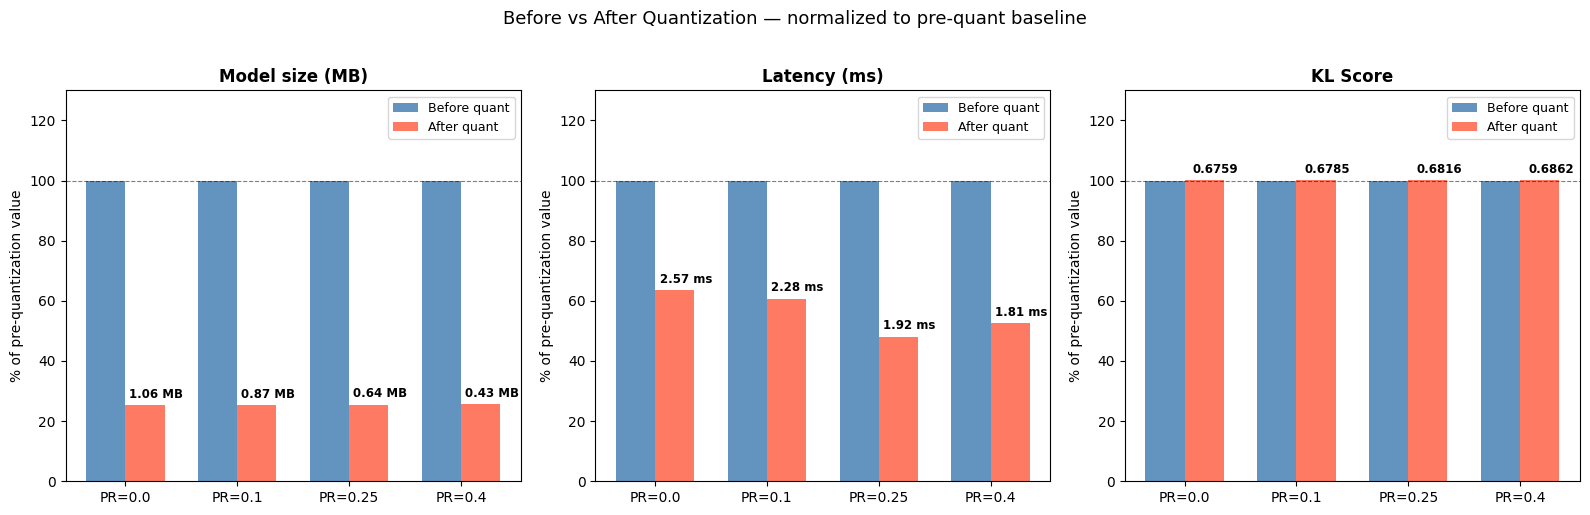

In [15]:
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv(DATA_DIR / "quantize_results.csv")

pruning_ratios = results_df["pruning_ratio"].tolist()
labels = [f"PR={r}" for r in pruning_ratios]

metrics = [
    ("sizes_before",   "sizes_after",   "Model size (MB)",   "{:.2f} MB"),
    ("latency_before", "latency_after", "Latency (ms)",      "{:.2f} ms"),
    ("score_before",   "score_after",   "KL Score",          "{:.4f}"),
]

x      = np.arange(len(pruning_ratios))
width  = 0.35
colors = {"before": "steelblue", "after": "tomato"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col_before, col_after, title, fmt) in zip(axes, metrics):
    before_vals = results_df[col_before].tolist()
    after_vals  = results_df[col_after].tolist()
    after_pct   = [a / b * 100 for a, b in zip(after_vals, before_vals)]

    ax.bar(x - width / 2, [100] * len(x), width, label="Before quant", color=colors["before"], alpha=0.85)
    bars_after = ax.bar(x + width / 2, after_pct, width, label="After quant", color=colors["after"], alpha=0.85)

    for bar, val in zip(bars_after, after_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2 + 0.1,
            bar.get_height() + 1.5,
            fmt.format(val),
            ha="center", va="bottom", fontsize=8.5, fontweight="bold"
        )

    ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("% of pre-quantization value")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 130)

plt.suptitle("Before vs After Quantization — normalized to pre-quant baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
